In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

df = pd.read_excel("../data/processed/BDD_CAPM_nettoyee.xlsx")
print("Dimensions :", df.shape)
df.head()

Dimensions : (22188, 12)


,Age Année,Sexe,Milieu,Région,Circonstance,Sous circonstance,type de produit1,Produit 1,Voie 1,Symptomatologie,Gradation finale,Tranche_age
0,25.0,Féminin,Urbain,Rabat-Salé-Kénitra,Inconnu,Inconnu,Médicament,SEROQUEL,Orale,Oui,Grade 2,16-30 ans
1,20.0,Féminin,Urbain,Casablanca-Settat,Inconnu,Inconnu,Médicament,LAROXYL,Orale,Oui,Grade 2,16-30 ans
2,16.0,Féminin,Urbain,Fès-Meknès,Accidentelle,Accident classique,Médicament,FLUOXETINE,Orale,Oui,Grade 2,16-30 ans
3,2.0,Masculin,Urbain,Fès-Meknès,Accidentelle,Erreur thérapeutique,Médicament,CODETUX,Orale,Oui,Grade 0,0-5 ans
4,32.0,Masculin,Inconnu,Casablanca-Settat,Accidentelle,Effet indésirable,Médicament,MEDICAMENT INCONNU,Inconnu,Oui,Grade 2,31-60 ans


In [2]:
features = ['Age Année', 'Sexe', 'Milieu', 'Région', 'Circonstance',
            'Sous circonstance', 'type de produit1', 'Produit 1', ' Voie 1', 'Tranche_age']

X = df[features].copy()
y = df['Gradation finale'].copy()

print("X shape :", X.shape)
print("y distribution :")
print(y.value_counts())

X shape : (22188, 10)
y distribution :
Gradation finale
Grade 2    9932
Grade 0    7929
Grade 1    3567
Grade 3     605
Grade 4     155
Name: count, dtype: int64


In [3]:
for col in features:
    print(f"{col} : {X[col].nunique()} valeurs uniques")

Age Année : 110 valeurs uniques
Sexe : 3 valeurs uniques
Milieu : 3 valeurs uniques
Région : 13 valeurs uniques
Circonstance : 4 valeurs uniques
Sous circonstance : 13 valeurs uniques
type de produit1 : 14 valeurs uniques
Produit 1 : 5960 valeurs uniques
 Voie 1 : 7 valeurs uniques
Tranche_age : 5 valeurs uniques


In [4]:
features = ['Age Année', 'Sexe', 'Milieu', 'Région', 'Circonstance',
            'Sous circonstance', 'type de produit1', ' Voie 1', 'Tranche_age']

X = df[features].copy()
y = df['Gradation finale'].copy()

print("X shape :", X.shape)
print(X.dtypes)

X shape : (22188, 9)
Age Année            float64
Sexe                     str
Milieu                   str
Région                   str
Circonstance             str
Sous circonstance        str
type de produit1         str
 Voie 1                  str
Tranche_age              str
dtype: object


In [5]:
variables_numeriques = ['Age Année']
variables_categorielles = ['Sexe', 'Milieu', 'Région', 'Circonstance',
                            'Sous circonstance', 'type de produit1', ' Voie 1', 'Tranche_age']

print("Numériques :", variables_numeriques)
print("Catégorielles :", variables_categorielles)

Numériques : ['Age Année']
Catégorielles : ['Sexe', 'Milieu', 'Région', 'Circonstance', 'Sous circonstance', 'type de produit1', ' Voie 1', 'Tranche_age']


In [6]:
X_encoded = pd.get_dummies(X, columns=variables_categorielles, drop_first=False)

print("Dimensions après encodage :", X_encoded.shape)
print("\nExemple de nouvelles colonnes créées :")
print(X_encoded.columns.tolist()[:20])

Dimensions après encodage : (22188, 63)

Exemple de nouvelles colonnes créées :
['Age Année', 'Sexe_Féminin', 'Sexe_Inconnu', 'Sexe_Masculin', 'Milieu_Inconnu', 'Milieu_Rural', 'Milieu_Urbain', 'Région_Béni Mellal-Khénifra', 'Région_Casablanca-Settat', 'Région_Dakhla-Oued Eddahab', 'Région_Drâa-Tafilalet', 'Région_Fès-Meknès', 'Région_Guelmim-Oued Noun', 'Région_Inconnu', "Région_L'Oriental", 'Région_Laâyoune-Sakia El Hamra', 'Région_Marrakech-Safi', 'Région_Rabat-Salé-Kénitra', 'Région_Souss-Massa', 'Région_Tanger-Tetouan-Al Hoceima']


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Taille train :", X_train.shape)
print("Taille test :", X_test.shape)
print("\nDistribution dans train :")
print(y_train.value_counts(normalize=True).sort_index() * 100)
print("\nDistribution dans test :")
print(y_test.value_counts(normalize=True).sort_index() * 100)

Taille train : (17750, 63)
Taille test : (4438, 63)

Distribution dans train :
Gradation finale
Grade 0    35.735211
Grade 1    16.078873
Grade 2    44.760563
Grade 3     2.726761
Grade 4     0.698592
Name: proportion, dtype: float64

Distribution dans test :
Gradation finale
Grade 0    35.736818
Grade 1    16.065795
Grade 2    44.772420
Grade 3     2.726453
Grade 4     0.698513
Name: proportion, dtype: float64


In [8]:
%pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("Avant SMOTE :", y_train.value_counts().sort_index())
print("\nAprès SMOTE :", y_train_smote.value_counts().sort_index())
print("\nNouvelle taille de X_train :", X_train_smote.shape)

Avant SMOTE : Gradation finale
Grade 0    6343
Grade 1    2854
Grade 2    7945
Grade 3     484
Grade 4     124
Name: count, dtype: int64

Après SMOTE : Gradation finale
Grade 0    7945
Grade 1    7945
Grade 2    7945
Grade 3    7945
Grade 4    7945
Name: count, dtype: int64

Nouvelle taille de X_train : (39725, 63)


In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

print("=== Modèle baseline (sans rééquilibrage) ===")
print(classification_report(y_test, y_pred_base))

=== Modèle baseline (sans rééquilibrage) ===
              precision    recall  f1-score   support

     Grade 0       0.61      0.67      0.64      1586
     Grade 1       0.33      0.06      0.11       713
     Grade 2       0.59      0.76      0.66      1987
     Grade 3       0.00      0.00      0.00       121
     Grade 4       0.00      0.00      0.00        31

    accuracy                           0.59      4438
   macro avg       0.31      0.30      0.28      4438
weighted avg       0.54      0.59      0.54      4438



c:\Users\Micro\CAPM_PROJECT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Micro\CAPM_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Micro\CAPM_PROJECT\venv\Lib\site-packages\sklearn\metrics\_cl

In [11]:
print(X_train.dtypes.value_counts())
print(X_train.isna().sum().sum())

bool       62
float64     1
Name: count, dtype: int64
0


In [12]:
print(X_train.dtypes.value_counts())
print("Valeurs manquantes dans X_train :", X_train.isna().sum().sum())
print("Valeurs manquantes dans y_train :", y_train.isna().sum())

bool       62
float64     1
Name: count, dtype: int64
Valeurs manquantes dans X_train : 0
Valeurs manquantes dans y_train : 0


In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train, y_train)

y_pred_base = model_base.predict(X_test)

print("=== Modèle baseline (sans rééquilibrage) ===")
print(classification_report(y_test, y_pred_base))

=== Modèle baseline (sans rééquilibrage) ===
              precision    recall  f1-score   support

     Grade 0       0.61      0.67      0.64      1586
     Grade 1       0.33      0.06      0.11       713
     Grade 2       0.59      0.76      0.66      1987
     Grade 3       0.00      0.00      0.00       121
     Grade 4       0.00      0.00      0.00        31

    accuracy                           0.59      4438
   macro avg       0.31      0.30      0.28      4438
weighted avg       0.54      0.59      0.54      4438



c:\Users\Micro\CAPM_PROJECT\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\Micro\CAPM_PROJECT\venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Micro\CAPM_PROJECT\venv\Lib\site-packages\sklearn\metrics\_cl

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled['Age Année'] = scaler.fit_transform(X_train[['Age Année']])
X_test_scaled['Age Année'] = scaler.transform(X_test[['Age Année']])

print(X_train_scaled['Age Année'].describe())

count    1.775000e+04
mean     3.762874e-17
std      1.000028e+00
min     -1.129915e+00
25%     -8.885491e-01
50%     -1.041113e-01
75%      4.389610e-01
max      4.662857e+00
Name: Age Année, dtype: float64


In [15]:
model_base = LogisticRegression(max_iter=1000, random_state=42)
model_base.fit(X_train_scaled, y_train)

y_pred_base = model_base.predict(X_test_scaled)

print("=== Modèle baseline (avec standardisation) ===")
print(classification_report(y_test, y_pred_base, zero_division=0))

=== Modèle baseline (avec standardisation) ===
              precision    recall  f1-score   support

     Grade 0       0.61      0.67      0.64      1586
     Grade 1       0.33      0.06      0.11       713
     Grade 2       0.59      0.76      0.66      1987
     Grade 3       0.00      0.00      0.00       121
     Grade 4       0.00      0.00      0.00        31

    accuracy                           0.59      4438
   macro avg       0.31      0.30      0.28      4438
weighted avg       0.53      0.59      0.54      4438



In [16]:
# Modèle avec pondération de classes
model_weighted = LogisticRegression(max_iter=2000, random_state=42, class_weight='balanced')
model_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = model_weighted.predict(X_test_scaled)

print("=== Modèle avec pondération de classes ===")
print(classification_report(y_test, y_pred_weighted, zero_division=0))

=== Modèle avec pondération de classes ===
              precision    recall  f1-score   support

     Grade 0       0.63      0.60      0.62      1586
     Grade 1       0.30      0.34      0.31       713
     Grade 2       0.75      0.34      0.47      1987
     Grade 3       0.05      0.28      0.09       121
     Grade 4       0.03      0.61      0.06        31

    accuracy                           0.43      4438
   macro avg       0.35      0.43      0.31      4438
weighted avg       0.61      0.43      0.48      4438



In [17]:
X_train_smote_scaled = X_train_smote.copy()
X_train_smote_scaled['Age Année'] = scaler.transform(X_train_smote[['Age Année']])

model_smote = LogisticRegression(max_iter=2000, random_state=42)
model_smote.fit(X_train_smote_scaled, y_train_smote)
y_pred_smote = model_smote.predict(X_test_scaled)

print("=== Modèle entraîné sur données SMOTE ===")
print(classification_report(y_test, y_pred_smote, zero_division=0))

=== Modèle entraîné sur données SMOTE ===
              precision    recall  f1-score   support

     Grade 0       0.60      0.69      0.64      1586
     Grade 1       0.36      0.25      0.29       713
     Grade 2       0.63      0.66      0.64      1987
     Grade 3       0.00      0.00      0.00       121
     Grade 4       0.15      0.06      0.09        31

    accuracy                           0.58      4438
   macro avg       0.35      0.33      0.33      4438
weighted avg       0.55      0.58      0.56      4438



In [18]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

print("=== Random Forest (class_weight='balanced') ===")
print(classification_report(y_test, y_pred_rf, zero_division=0))

=== Random Forest (class_weight='balanced') ===
              precision    recall  f1-score   support

     Grade 0       0.62      0.65      0.63      1586
     Grade 1       0.39      0.45      0.42       713
     Grade 2       0.71      0.59      0.64      1987
     Grade 3       0.12      0.26      0.17       121
     Grade 4       0.08      0.16      0.11        31

    accuracy                           0.58      4438
   macro avg       0.39      0.42      0.39      4438
weighted avg       0.61      0.58      0.59      4438



In [19]:
%pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [20]:
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

# XGBoost a besoin d'une cible numérique (0,1,2,3,4) plutôt que du texte "Grade 0", "Grade 1"...
le = LabelEncoder()
y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# Calcul manuel des poids par échantillon (XGBoost n'a pas de class_weight='balanced' intégré)
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train_encoded)

model_xgb = XGBClassifier(
    n_estimators=200,
    random_state=42,
    eval_metric='mlogloss'
)
model_xgb.fit(X_train, y_train_encoded, sample_weight=sample_weights)

y_pred_xgb_encoded = model_xgb.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

print("=== XGBoost (pondération via sample_weight) ===")
print(classification_report(y_test, y_pred_xgb, zero_division=0))

=== XGBoost (pondération via sample_weight) ===
              precision    recall  f1-score   support

     Grade 0       0.62      0.70      0.66      1586
     Grade 1       0.41      0.42      0.42       713
     Grade 2       0.74      0.55      0.63      1987
     Grade 3       0.10      0.29      0.14       121
     Grade 4       0.06      0.16      0.09        31

    accuracy                           0.57      4438
   macro avg       0.39      0.42      0.39      4438
weighted avg       0.62      0.57      0.59      4438



In [21]:
from sklearn.model_selection import RandomizedSearchCV

param_grid_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': ['balanced', 'balanced_subsample']
}

random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_grid_rf,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_rf.fit(X_train, y_train)

print("Meilleurs paramètres :", random_search_rf.best_params_)
print("Meilleur score F1-macro (validation croisée) :", random_search_rf.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 20, 'class_weight': 'balanced_subsample'}
Meilleur score F1-macro (validation croisée) : 0.4073269279071126


In [22]:
best_rf = random_search_rf.best_estimator_
y_pred_best_rf = best_rf.predict(X_test)

print("=== Random Forest optimisé ===")
print(classification_report(y_test, y_pred_best_rf, zero_division=0))

=== Random Forest optimisé ===
              precision    recall  f1-score   support

     Grade 0       0.62      0.72      0.66      1586
     Grade 1       0.45      0.39      0.42       713
     Grade 2       0.71      0.62      0.66      1987
     Grade 3       0.17      0.26      0.21       121
     Grade 4       0.12      0.19      0.15        31

    accuracy                           0.61      4438
   macro avg       0.41      0.44      0.42      4438
weighted avg       0.62      0.61      0.61      4438



In [23]:
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}

random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='mlogloss'),
    param_distributions=param_grid_xgb,
    n_iter=20,
    scoring='f1_macro',
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search_xgb.fit(X_train, y_train_encoded, sample_weight=sample_weights)

print("Meilleurs paramètres :", random_search_xgb.best_params_)
print("Meilleur score F1-macro (validation croisée) :", random_search_xgb.best_score_)

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Meilleurs paramètres : {'subsample': 0.7, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.05, 'colsample_bytree': 0.7}
Meilleur score F1-macro (validation croisée) : 0.46074722510059196


In [24]:
best_xgb = random_search_xgb.best_estimator_
y_pred_best_xgb_encoded = best_xgb.predict(X_test)
y_pred_best_xgb = le.inverse_transform(y_pred_best_xgb_encoded)

print("=== XGBoost optimisé ===")
print(classification_report(y_test, y_pred_best_xgb, zero_division=0))

=== XGBoost optimisé ===
              precision    recall  f1-score   support

     Grade 0       0.64      0.66      0.65      1586
     Grade 1       0.38      0.39      0.39       713
     Grade 2       0.80      0.45      0.58      1987
     Grade 3       0.08      0.40      0.13       121
     Grade 4       0.05      0.52      0.09        31

    accuracy                           0.51      4438
   macro avg       0.39      0.48      0.36      4438
weighted avg       0.65      0.51      0.56      4438



In [25]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Sur le Random Forest optimisé
scores_rf = cross_val_score(best_rf, X_encoded, y, cv=skf, scoring='f1_macro', n_jobs=-1)
print("Random Forest — F1-macro sur 5 folds :", scores_rf)
print("Moyenne :", scores_rf.mean(), "  Écart-type :", scores_rf.std())

Random Forest — F1-macro sur 5 folds : [0.40271101 0.44917655 0.42360167 0.41220761 0.42778865]
Moyenne : 0.42309709600306933   Écart-type : 0.015726260900264064


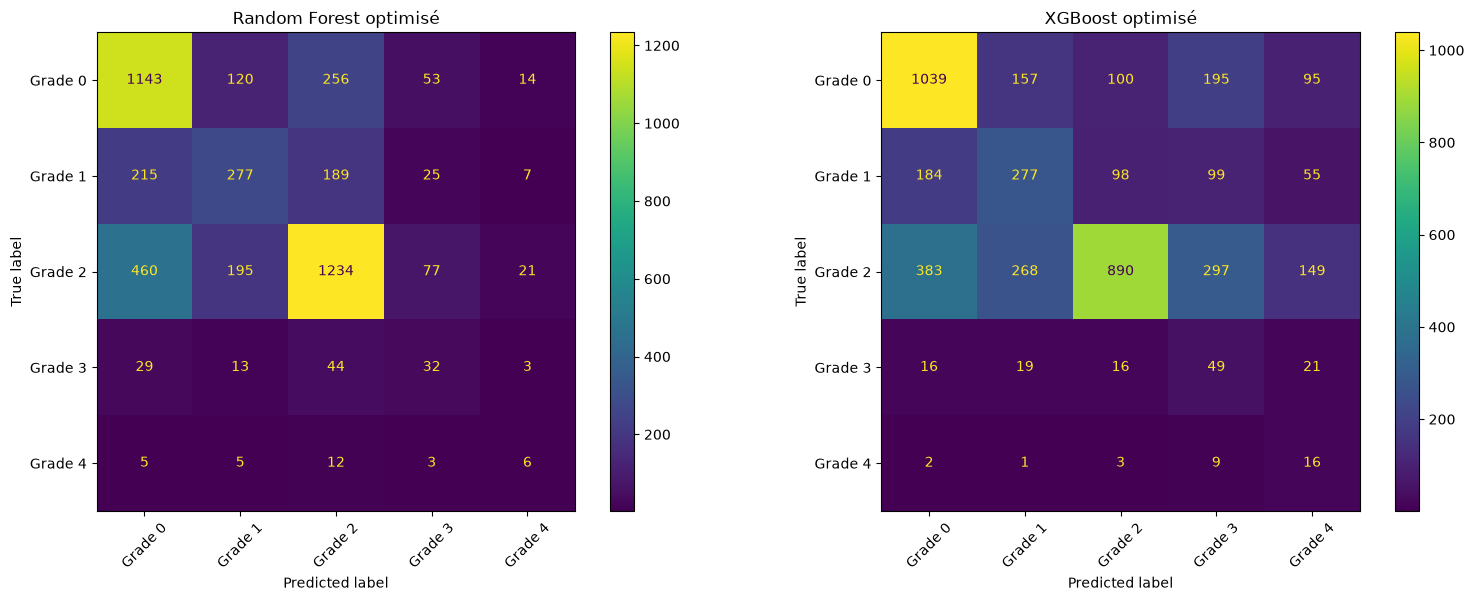

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_rf, ax=axes[0], xticks_rotation=45)
axes[0].set_title("Random Forest optimisé")

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_best_xgb, ax=axes[1], xticks_rotation=45)
axes[1].set_title("XGBoost optimisé")

plt.tight_layout()
plt.show()

In [27]:
print("Nombre total prédictions Grade 4 (RF) :", (y_pred_best_rf == "Grade 4").sum())
print("Nombre total prédictions Grade 4 (XGB) :", (y_pred_best_xgb == "Grade 4").sum())
print("Nombre réel de Grade 4 dans y_test :", (y_test == "Grade 4").sum())

Nombre total prédictions Grade 4 (RF) : 51
Nombre total prédictions Grade 4 (XGB) : 336
Nombre réel de Grade 4 dans y_test : 31


In [28]:
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [30]:
import shap

X_test_sample = X_test.sample(n=300, random_state=42)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sample)

print("Type de shap_values :", type(shap_values))
print("Forme :", np.array(shap_values).shape)

Type de shap_values : <class 'numpy.ndarray'>
Forme : (300, 63, 5)


In [31]:
X_test_sample = X_test.sample(n=300, random_state=42)

explainer = shap.TreeExplainer(best_rf)
shap_values = explainer.shap_values(X_test_sample)

print("Type de shap_values :", type(shap_values))
print("Forme :", np.array(shap_values).shape)

Type de shap_values : <class 'numpy.ndarray'>
Forme : (300, 63, 5)


In [32]:
best_rf = RandomForestClassifier(
    n_estimators=200,
    min_samples_split=5,
    min_samples_leaf=1,
    max_depth=20,
    class_weight='balanced_subsample',
    random_state=42,
    n_jobs=-1
)
best_rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced_subsample'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider

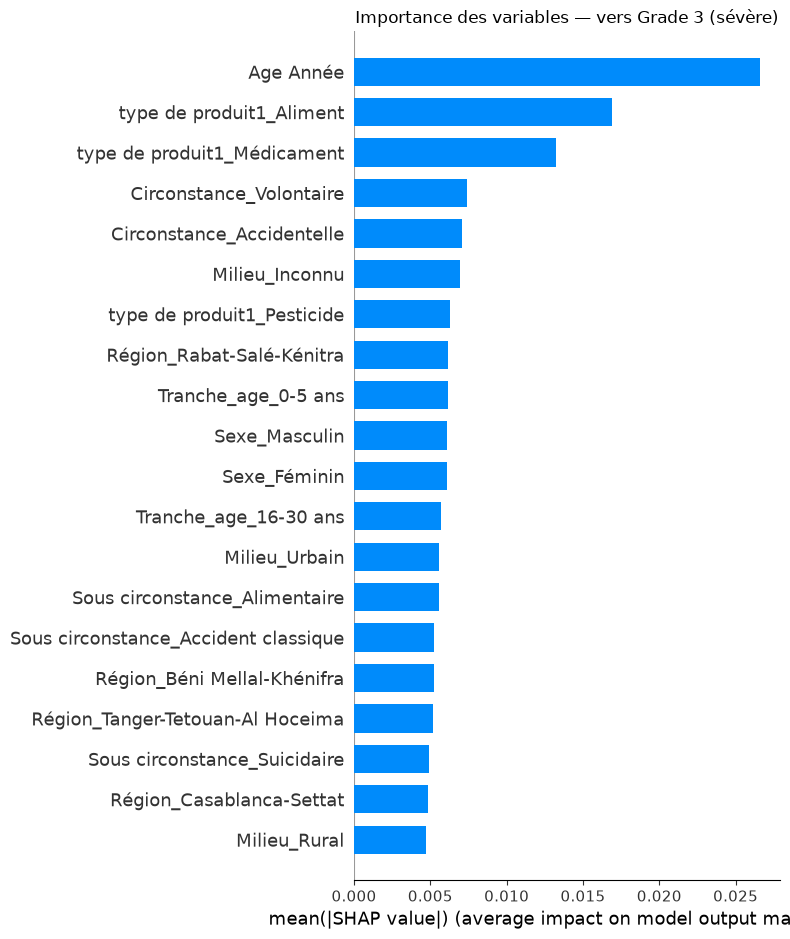

In [33]:
shap.summary_plot(shap_values[:, :, 3], X_test_sample, plot_type="bar", show=False)
plt.title("Importance des variables — vers Grade 3 (sévère)")
plt.tight_layout()
plt.show()

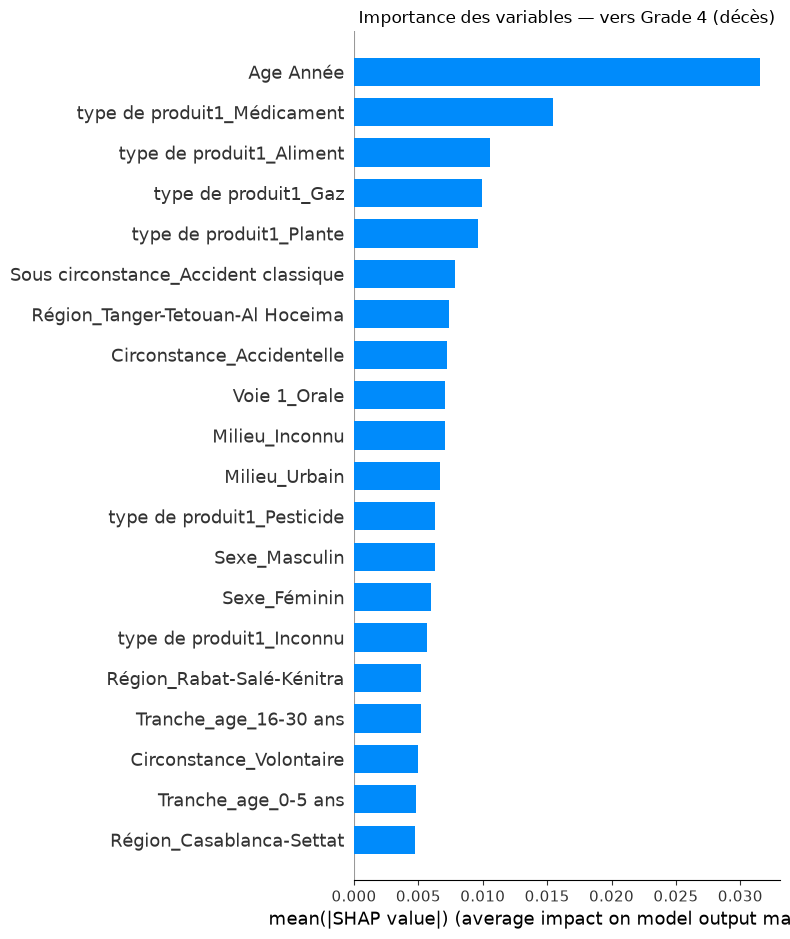

In [34]:
shap.summary_plot(shap_values[:, :, 4], X_test_sample, plot_type="bar", show=False)
plt.title("Importance des variables — vers Grade 4 (décès)")
plt.tight_layout()
plt.show()

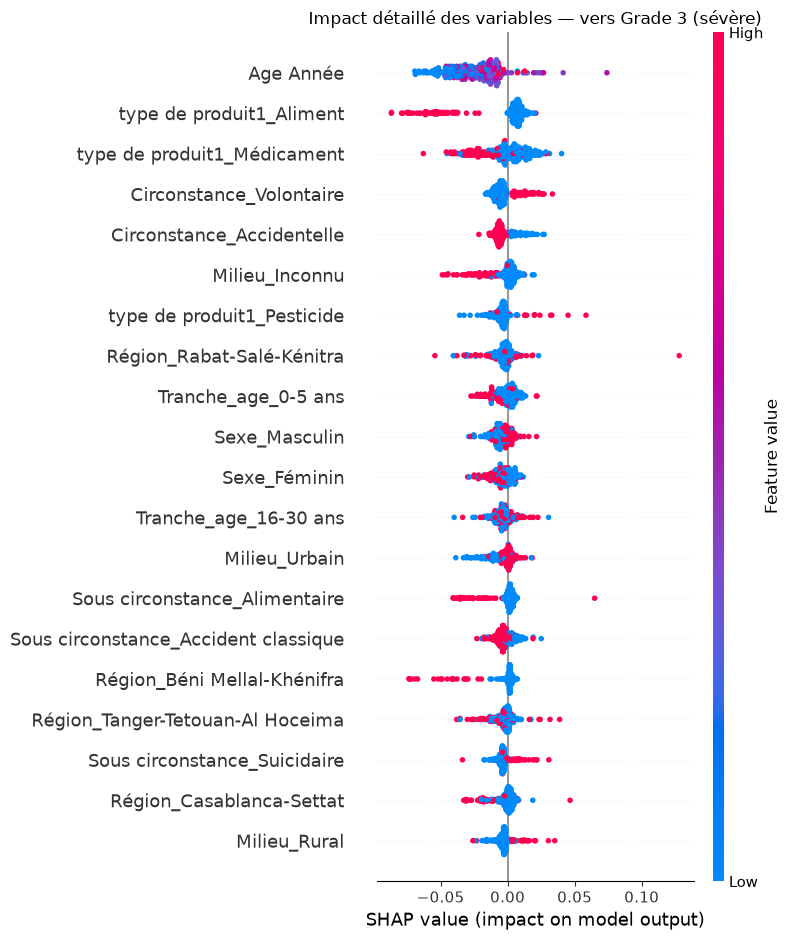

In [35]:
shap.summary_plot(shap_values[:, :, 3], X_test_sample, show=False)
plt.title("Impact détaillé des variables — vers Grade 3 (sévère)")
plt.tight_layout()
plt.show()

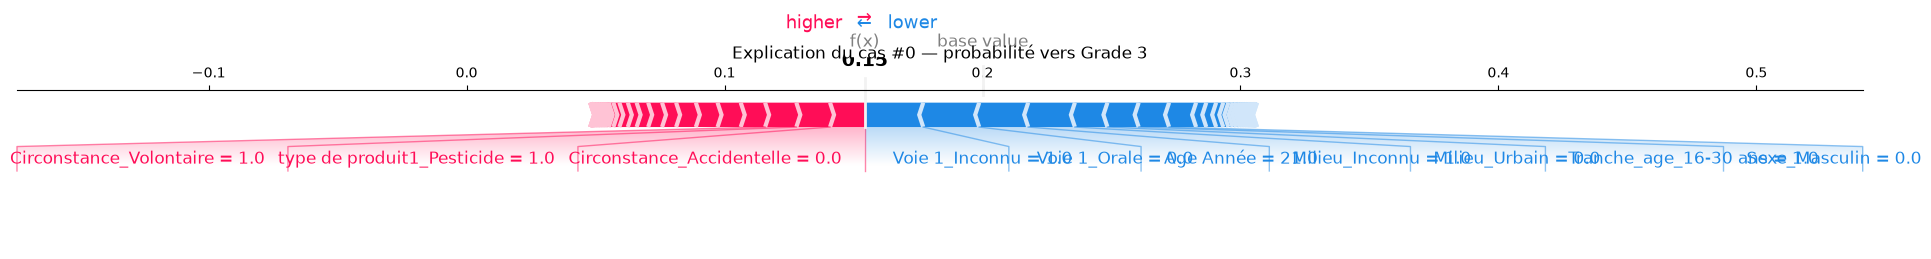

Vraie classe de ce patient : Grade 0


In [36]:
idx = 0  # on prend le premier patient de l'échantillon, à ajuster si besoin

shap.force_plot(
    explainer.expected_value[3],
    shap_values[idx, :, 3],
    X_test_sample.iloc[idx],
    matplotlib=True,
    show=False
)
plt.title(f"Explication du cas #{idx} — probabilité vers Grade 3")
plt.tight_layout()
plt.show()

print("Vraie classe de ce patient :", y_test.loc[X_test_sample.index[idx]])

In [37]:
prediction_finale = best_rf.predict(X_test_sample.iloc[[idx]])
probabilites = best_rf.predict_proba(X_test_sample.iloc[[idx]])

print("Grade prédit par le modèle :", prediction_finale[0])
print("Probabilités par grade :", dict(zip(best_rf.classes_, probabilites[0].round(3))))

Grade prédit par le modèle : Grade 1
Probabilités par grade : {'Grade 0': np.float64(0.248), 'Grade 1': np.float64(0.487), 'Grade 2': np.float64(0.093), 'Grade 3': np.float64(0.154), 'Grade 4': np.float64(0.018)}


In [38]:
# Trouver un exemple où la vraie classe est Grade 4 dans l'échantillon
indices_grade4 = X_test_sample.index[y_test.loc[X_test_sample.index] == "Grade 4"]
print("Indices avec vraie classe Grade 4 dans l'échantillon :", indices_grade4.tolist())

Indices avec vraie classe Grade 4 dans l'échantillon : [2482, 9844]


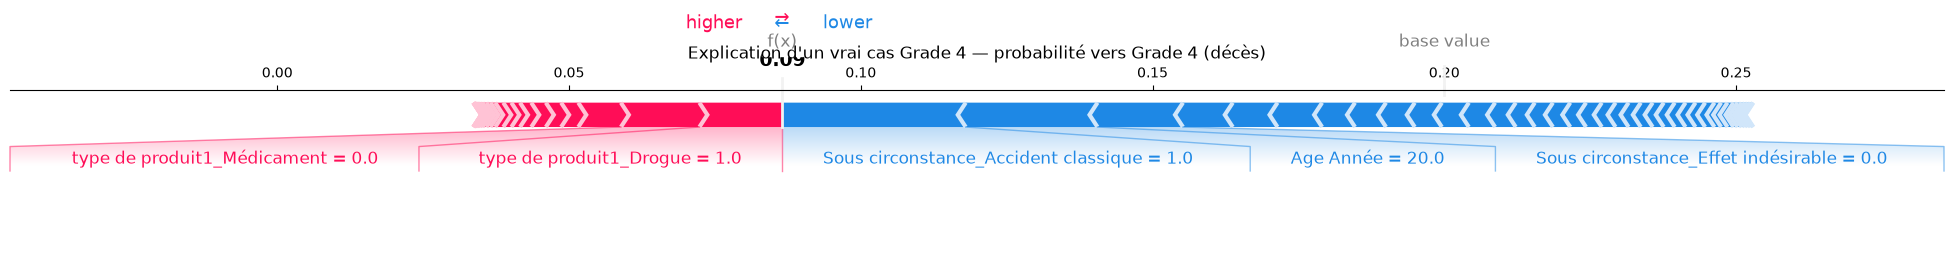

Grade prédit par le modèle : Grade 3
Probabilités par grade : {'Grade 0': np.float64(0.182), 'Grade 1': np.float64(0.199), 'Grade 2': np.float64(0.265), 'Grade 3': np.float64(0.267), 'Grade 4': np.float64(0.087)}
Vraie classe : Grade 4


In [39]:
# On récupère la position de cet index dans X_test_sample (pas l'index lui-même)
idx_grade4 = X_test_sample.index.get_loc(2482)

shap.force_plot(
    explainer.expected_value[4],
    shap_values[idx_grade4, :, 4],
    X_test_sample.iloc[idx_grade4],
    matplotlib=True,
    show=False
)
plt.title("Explication d'un vrai cas Grade 4 — probabilité vers Grade 4 (décès)")
plt.tight_layout()
plt.show()

prediction_finale = best_rf.predict(X_test_sample.loc[[2482]])
probabilites = best_rf.predict_proba(X_test_sample.loc[[2482]])

print("Grade prédit par le modèle :", prediction_finale[0])
print("Probabilités par grade :", dict(zip(best_rf.classes_, probabilites[0].round(3))))
print("Vraie classe : Grade 4")

In [40]:
from sklearn.metrics import cohen_kappa_score

# On encode les grades en nombres ordonnés (0,1,2,3,4) pour que la pondération "quadratique" ait un sens
y_test_num = y_test.str.extract(r'(\d)').astype(int)[0]
y_pred_num = pd.Series(y_pred_best_rf).str.extract(r'(\d)').astype(int)[0]

qwk = cohen_kappa_score(y_test_num, y_pred_num, weights='quadratic')

print("Quadratic Weighted Kappa (Random Forest optimisé) :", round(qwk, 3))

Quadratic Weighted Kappa (Random Forest optimisé) : 0.429


In [41]:
resultats_finaux = []

modeles_predictions = {
    "Logistique (baseline)": y_pred_base,
    "Logistique (class_weight)": y_pred_weighted,
    "Random Forest (optimisé)": y_pred_best_rf,
    "XGBoost (optimisé)": y_pred_best_xgb,
}

for nom, y_pred in modeles_predictions.items():
    y_pred_num_temp = pd.Series(y_pred).str.extract(r'(\d)').astype(int)[0]
    qwk_temp = cohen_kappa_score(y_test_num, y_pred_num_temp, weights='quadratic')
    resultats_finaux.append({"Modèle": nom, "Quadratic Weighted Kappa": round(qwk_temp, 3)})

df_comparaison_finale = pd.DataFrame(resultats_finaux).sort_values("Quadratic Weighted Kappa", ascending=False)
print(df_comparaison_finale.to_string(index=False))

                   Modèle  Quadratic Weighted Kappa
 Random Forest (optimisé)                     0.429
    Logistique (baseline)                     0.394
       XGBoost (optimisé)                     0.337
Logistique (class_weight)                     0.293


In [42]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

joblib.dump(best_rf, "../models/random_forest_capm.pkl")
joblib.dump(le, "../models/label_encoder_capm.pkl")

# Sauvegarder aussi la liste exacte des colonnes attendues par le modèle (essentiel pour l'API)
joblib.dump(X_encoded.columns.tolist(), "../models/colonnes_modele.pkl")

print("Modèle et fichiers associés sauvegardés dans /models")

Modèle et fichiers associés sauvegardés dans /models


In [43]:
pip install fastapi uvicorn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
from fastapi import FastAPI
from pydantic import BaseModel
import joblib
import pandas as pd

# Chargement du modèle et des fichiers associés (une seule fois, au démarrage de l'API)
model = joblib.load("../models/random_forest_capm.pkl")
label_encoder = joblib.load("../models/label_encoder_capm.pkl")
colonnes_modele = joblib.load("../models/colonnes_modele.pkl")

app = FastAPI(title="API de prédiction de gravité des intoxications - CAPM")


# Définition de la structure des données attendues en entrée
class CasIntoxication(BaseModel):
    age: float
    sexe: str
    milieu: str
    region: str
    circonstance: str
    sous_circonstance: str
    type_produit: str
    voie: str
    tranche_age: str


@app.get("/")
def accueil():
    return {"message": "API CAPM opérationnelle. Utilisez /predict pour obtenir une prédiction."}


@app.post("/predict")
def predire_gravite(cas: CasIntoxication):
    # Construction d'une ligne de données au format attendu par le modèle
    donnees_brutes = pd.DataFrame([{
        "Age Année": cas.age,
        "Sexe": cas.sexe,
        "Milieu": cas.milieu,
        "Région": cas.region,
        "Circonstance": cas.circonstance,
        "Sous circonstance": cas.sous_circonstance,
        "type de produit1": cas.type_produit,
        " Voie 1": cas.voie,
        "Tranche_age": cas.tranche_age,
    }])

    # One-hot encoding, comme à l'entraînement
    donnees_encodees = pd.get_dummies(donnees_brutes)

    # Aligner les colonnes exactement comme celles du modèle (colonnes manquantes = 0)
    donnees_finales = donnees_encodees.reindex(columns=colonnes_modele, fill_value=0)

    # Prédiction
    prediction = model.predict(donnees_finales)[0]
    probabilites = model.predict_proba(donnees_finales)[0]

    return {
        "grade_predit": prediction,
        "probabilites": dict(zip(model.classes_, probabilites.round(3).tolist()))
    }